## Tarefa 1 — Preparação

Carregamento do dataset e seperação dos dados (treino e teste)

In [2]:
import warnings 
# Ignorar apenas FutureWarning
warnings.simplefilter(action="ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
# Bibliotecas dos algoritmos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import silhouette_score

# Biblioteca para normalização dos dados
from sklearn.preprocessing import StandardScaler

# Bibliotecas para matriz de confusão, curca de roc, plotagem de gráficos
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt


#Carregando o dataset REAL: UCI Heart Disease (Cleveland)
url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df_dataset = pd.read_csv(url, sep=",")

print(df_dataset.head())
print("\nDimensões:", df_dataset.shape)
print("\nDistribuição das classes (target):")
print(df_dataset["target"].value_counts())

# Separação features e alvo (Y)
X = df_dataset.drop(columns=["target"])
y = df_dataset["target"]

#Separação de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

#Padronizando os dados na mesma escala
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

Dimensões: (303, 14)

Distribuição das classes (target):
target
1    165
0    138
Name: count, dtype: int64


## Tarefa 2 — Treinamento dos modelos 

Treinar o modelo nos algoritmos:

1. Regressão logística
2. Árvore de Decisão (Decision Tree) e Random Forest
3. KNN (K-Nearest Neighbors) 
4. SVM (Support Vector Machine)
5. Naive Bayes (GaussianNB)

In [3]:
# Treinamento do modelo no algoritmo de Regressão Logística

print("--- Regressão Logística ---")

modeloLogisticRegression = LogisticRegression(max_iter=1000)

inicio = time.time()
modeloLogisticRegression.fit(X_train_scaled, y_train)
fim = time.time()

tempo_rl = fim - inicio

y_pred_LogisticRegression = modeloLogisticRegression.predict(X_test_scaled)
y_prob_LogisticRegression = modeloLogisticRegression.predict_proba(X_test_scaled)[:,1]
acc_lr = accuracy_score(y_test, y_pred_LogisticRegression)

print(f"Tempo: {fim - inicio:.4f}s | Acurácia: {acc_lr:.4f}")


--- Regressão Logística ---
Tempo: 0.0187s | Acurácia: 0.7582


In [4]:
# Treinamento do modelo nos algoritmos de Árvore de Decisão (Decision Tree) e Random Forest

# Valores de profundidade a serem testados
profundidades = [3, 6] 

print("--- Árvore de Decisão ---")
for d in profundidades:
    modelo_dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    
    # Capturando o tempo de treinamento
    inicio = time.time()
    modelo_dt.fit(X_train_scaled, y_train)
    fim = time.time()
    
    # Previsões e probabilidades
    y_pred_dt = modelo_dt.predict(X_test_scaled)
    y_prob_dt = modelo_dt.predict_proba(X_test_scaled)[:, 1] 
    
    acc_dt = accuracy_score(y_test, y_pred_dt)
    print(f"Profundidade {d} | Tempo: {fim - inicio:.4f}s | Acurácia: {acc_dt:.4f}")

print("\n--- Random Forest ---")
for d in profundidades:
    modelo_rt = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=d)
    
    inicio = time.time()
    modelo_rt.fit(X_train_scaled, y_train)
    fim = time.time()
    
    y_pred_rt = modelo_rt.predict(X_test_scaled)
    y_prob_rt = modelo_rt.predict_proba(X_test_scaled)[:, 1] 
    
    acc_rt = accuracy_score(y_test, y_pred_rt)
    print(f"Profundidade {d} | Tempo: {fim - inicio:.4f}s | Acurácia: {acc_rt:.4f}")

# Salvando os melhores resultados dos modelos, para tarefa 3 de calcular métrica
modelo_dt = DecisionTreeClassifier(max_depth=6, random_state=42)
inicio = time.time()
modelo_dt.fit(X_train_scaled, y_train)
fim = time.time()
tempo_dt = fim - inicio
y_pred_dt = modelo_dt.predict(X_test_scaled)
y_prob_dt = modelo_dt.predict_proba(X_test_scaled)[:, 1]
acc_dt = accuracy_score(y_test, y_pred_dt)

modelo_rt = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=3)
inicio = time.time()
modelo_rt.fit(X_train_scaled, y_train)
fim =  time.time()
tempo_rt = fim - inicio
y_pred_rt = modelo_rt.predict(X_test_scaled)
y_prob_rt = modelo_rt.predict_proba(X_test_scaled)[:, 1]
acc_rt = accuracy_score(y_test, y_pred_rt)

--- Árvore de Decisão ---
Profundidade 3 | Tempo: 0.0053s | Acurácia: 0.7473
Profundidade 6 | Tempo: 0.0039s | Acurácia: 0.7582

--- Random Forest ---


Profundidade 3 | Tempo: 0.3369s | Acurácia: 0.8022
Profundidade 6 | Tempo: 0.4737s | Acurácia: 0.7912


In [5]:
# Treinamento do modelo KNN (K-Nearest Neighbors) 

# Valores de vizinhos a serem testados conforme a Tarefa 2
valores_vizinhos = [3, 5, 9]

for n in valores_vizinhos:

    modelo_knn = KNeighborsClassifier(n_neighbors=n)

    inicio = time.time()
    modelo_knn.fit(X_train_scaled, y_train)
    fim = time.time()
    
    y_pred_knn = modelo_knn.predict(X_test_scaled)
    y_prob_knn = modelo_knn.predict_proba(X_test_scaled)[:, 1]
    acc_knn = accuracy_score(y_test, y_pred_knn)
    print(f"Vizinhos {n} | Tempo: {fim - inicio:.4f}s | Acurácia: {acc_knn:.4f}")

# Definindo n_neighbors como sendo 9, iremos cacular métrica (Tarefa 3) com a melhor versão do modelo.
modelo_knn = KNeighborsClassifier(n_neighbors=9)
inicio = time.time()
modelo_knn.fit(X_train_scaled, y_train)
fim = time.time()

tempo_knn = fim - inicio

y_pred_knn = modelo_knn.predict(X_test_scaled)
y_prob_knn = modelo_knn.predict_proba(X_test_scaled)[:, 1]
acc_knn = accuracy_score(y_test, y_pred_knn)


Vizinhos 3 | Tempo: 0.0042s | Acurácia: 0.7473
Vizinhos 5 | Tempo: 0.0048s | Acurácia: 0.7912
Vizinhos 9 | Tempo: 0.0051s | Acurácia: 0.7912


In [6]:
# Treinamento do modelo SVM (Support Vector Machine)

print("--- SVM (Support Vector Machine) ---")
kernels = ['linear', 'rbf']

for k in kernels:
    # probability=True é obrigatório aqui para o roc_auc_score da Tarefa 3
    modelo_svm = SVC(kernel=k, probability=True, random_state=42)
    
    inicio = time.time()
    modelo_svm.fit(X_train_scaled, y_train)
    fim = time.time()
    
    y_pred_svm = modelo_svm.predict(X_test_scaled)
    y_prob_svm = modelo_svm.predict_proba(X_test_scaled)[:, 1]

    tempo_svm = fim - inicio    
    acc_svm = accuracy_score(y_test, y_pred_svm)
    print(f"Kernel '{k}' | Tempo: {tempo_svm:.4f}s | Acurácia: {acc_svm:.4f}")

--- SVM (Support Vector Machine) ---
Kernel 'linear' | Tempo: 0.0358s | Acurácia: 0.7582
Kernel 'rbf' | Tempo: 0.0170s | Acurácia: 0.7912


In [7]:
# Treinando o modelo Naive Bayes (GaussianNB)
modelo_nb = GaussianNB()

inicio = time.time()
modelo_nb.fit(X_train_scaled, y_train)
fim = time.time()

y_pred_nb = modelo_nb.predict(X_test_scaled)
y_prob_nb = modelo_nb.predict_proba(X_test_scaled)[:, 1]

tempo_naive = fim - inicio

print(f"Naive Bayes | Tempo: {tempo_naive:.4f}s | Acurácia: {accuracy_score(y_test, y_pred_nb):.4f}")

Naive Bayes | Tempo: 0.0078s | Acurácia: 0.7912


## Tarefa 3 — Cálculo dos parâmetros de avaliação

Para CADA um dos cinco algoritmos, calcule e registre em uma tabela comparativa (modelo similar à Tabela 1 
abaixo) os seguintes parâmetros, todos obtidos a partir da matriz de confusão do conjunto de teste:   

1.  Matriz de confusão completa (VP, VN, FP, FN). 
2.  Sensibilidade (Recall / Taxa de Verdadeiro Positivo) = VP / (VP + FN). 
3.  Especificidade (Taxa de Verdadeiro Negativo) = VN / (VN + FP). 
4.  Precisão (Precision) = VP / (VP + FP). 
5.  Acurácia (Accuracy) = (VP + VN) / (VP + VN + FP + FN). 
6.  F1-Score = 2 × (Precisão × Sensibilidade) / (Precisão + Sensibilidade). 
7.  AUC (área sob a curva ROC), calculado com roc_auc_score. 
8.  Tempo de treinamento do modelo, em segundos (use o módulo time do Python).

In [8]:
# Calcular as metricas e criar a tabela 1 conforme atividade

def calcular_metricas(nome_modelo, y_true, y_pred, y_prob, tempo):
    # Extraindo os valores da matriz de confusão
    vn, fp, fn, vp = confusion_matrix(y_true, y_pred).ravel()
    
    # Aplicando as fórmulas
    sensibilidade = vp / (vp + fn)
    especificidade = vn / (vn + fp)
    precisao = vp / (vp + fp)
    acuracia = (vp + vn) / (vp + vn + fp + fn)
    f1_score = 2 * (precisao * sensibilidade) / (precisao + sensibilidade)
    auc = roc_auc_score(y_true, y_prob)
    
    # Retorna os dados no formato exato das colunas da Tabela 1
    return {
        "Algoritmo": nome_modelo,
        "Sensibilidade": round(sensibilidade, 4),
        "Especificidade": round(especificidade, 4),
        "Precisão": round(precisao, 4),
        "Acurácia": round(acuracia, 4),
        "F1-Score": round(f1_score, 4),
        "AUC": round(auc, 4),
        "Tempo (s)": round(tempo, 4)
    }

# Criando uma lista para armazenar os resultados de todos os modelos
linhas_tabela = []

# Calculando as métricas e adicionando na lista 

linhas_tabela.append(calcular_metricas("Regressão Logística", y_test, y_pred_LogisticRegression, y_prob_LogisticRegression, tempo_rl))
linhas_tabela.append(calcular_metricas("Árvore de Decisão", y_test, y_pred_dt, y_prob_dt, tempo_dt))
linhas_tabela.append(calcular_metricas("Random Forest", y_test, y_pred_rt, y_prob_rt, tempo_rt))
linhas_tabela.append(calcular_metricas("KNN", y_test, y_pred_knn, y_prob_knn, tempo_knn))
linhas_tabela.append(calcular_metricas("SVM", y_test, y_pred_svm, y_prob_svm, tempo_svm))
linhas_tabela.append(calcular_metricas("Naive Bayes", y_test, y_pred_nb, y_prob_nb, tempo_naive))

# Gerando e exibindo a Tabela 1 usando Pandas
df_tabela1 = pd.DataFrame(linhas_tabela)

# O display renderiza uma tabela
display(df_tabela1)

,Algoritmo,Sensibilidade,Especificidade,Precisão,Acurácia,F1-Score,AUC,Tempo (s)
0,Regressão Logística,0.82,0.6829,0.7593,0.7582,0.7885,0.8639,0.0187
1,Árvore de Decisão,0.82,0.6829,0.7593,0.7582,0.7885,0.7515,0.0044
2,Random Forest,0.88,0.7073,0.7857,0.8022,0.8302,0.8698,0.3256
3,KNN,0.86,0.7073,0.7818,0.7912,0.8190,0.8590,0.0057
4,SVM,0.84,0.7317,0.7925,0.7912,0.8155,0.8522,0.0170
5,Naive Bayes,0.86,0.7073,0.7818,0.7912,0.8190,0.8517,0.0078


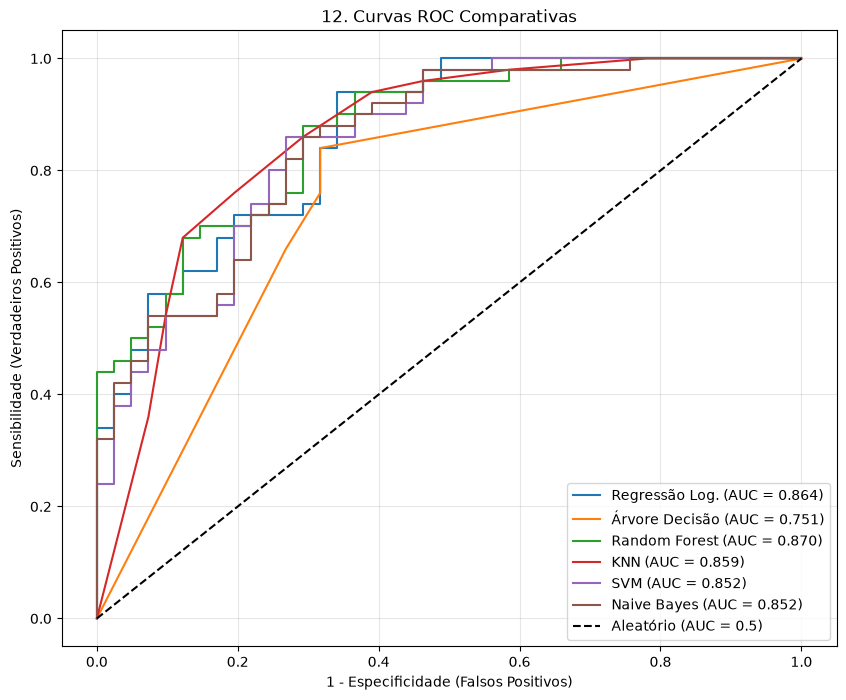

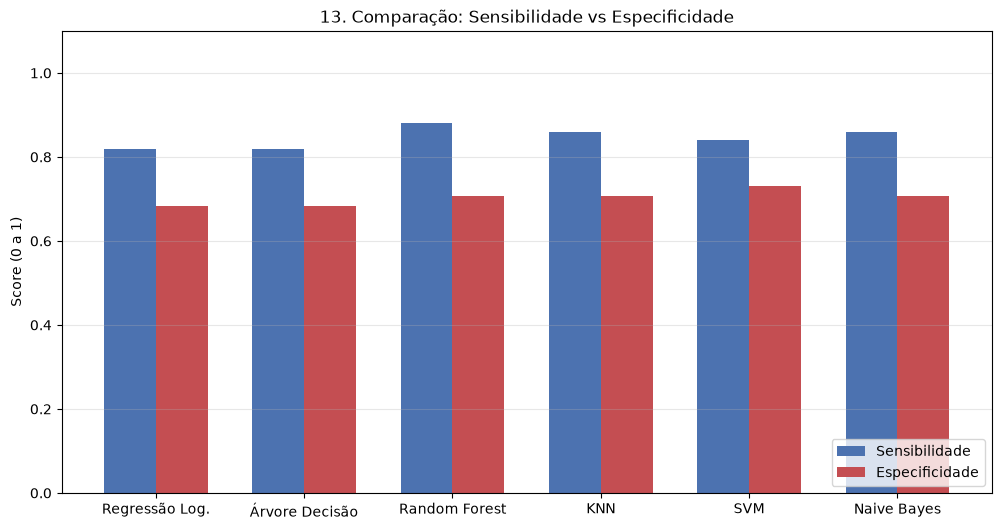

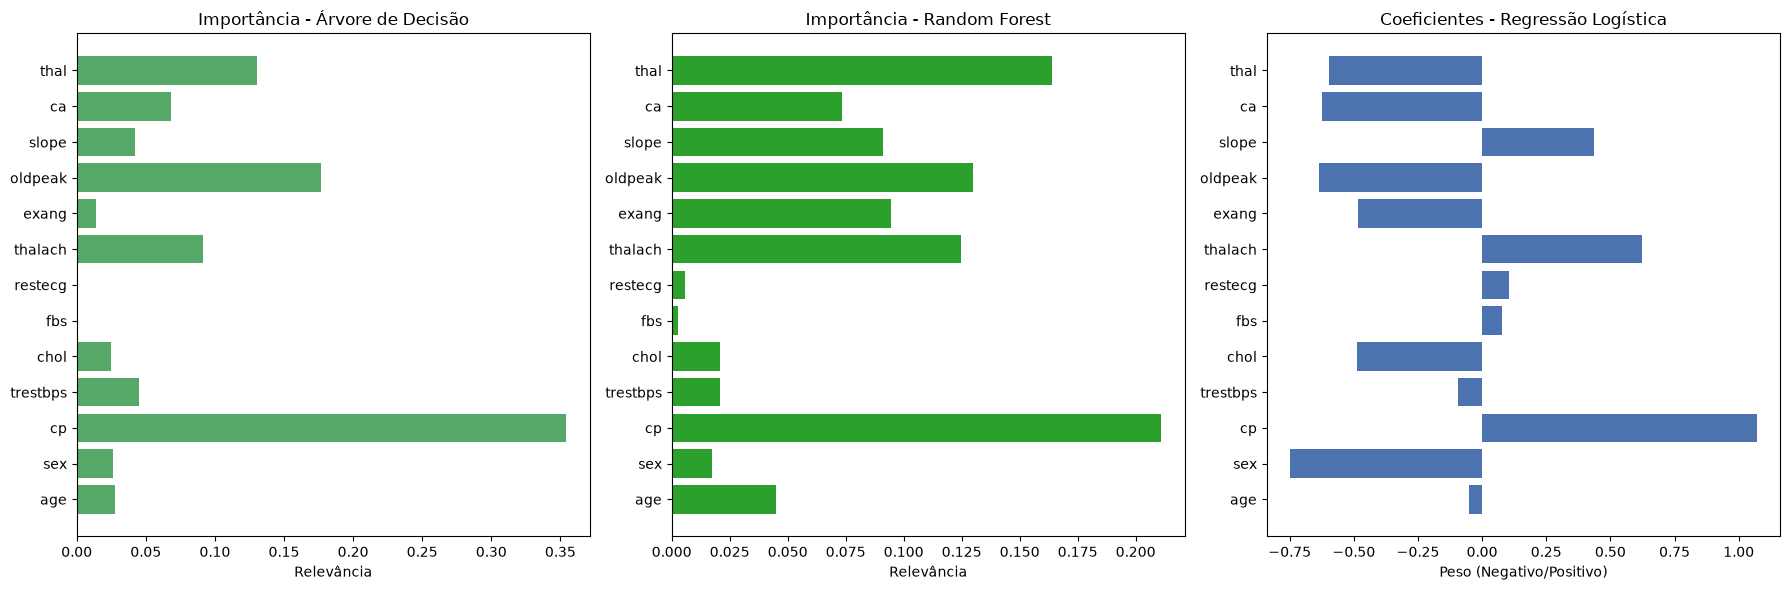

In [9]:
# preparação dos dados (agrupando os modelos)
nomes_modelos = ['Regressão Log.', 'Árvore Decisão', 'Random Forest', 'KNN', 'SVM', 'Naive Bayes']

# Lista das previsões (ajuste os nomes se os seus estiverem diferentes)
preds = [y_pred_LogisticRegression, y_pred_dt, y_pred_rt, y_pred_knn, y_pred_svm, y_pred_nb]

# Lista das probabilidades (usado para ROC/AUC)
probs = [y_prob_LogisticRegression, y_prob_dt, y_prob_rt, y_prob_knn, y_prob_svm, y_prob_nb]

# curvas roc sobrepostas
plt.figure(figsize=(10, 8))

for i in range(len(nomes_modelos)):
    fpr, tpr, _ = roc_curve(y_test, probs[i])
    auc = roc_auc_score(y_test, probs[i])
    plt.plot(fpr, tpr, label=f"{nomes_modelos[i]} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Aleatório (AUC = 0.5)")
plt.xlabel("1 - Especificidade (Falsos Positivos)")
plt.ylabel("Sensibilidade (Verdadeiros Positivos)")
plt.title("12. Curvas ROC Comparativas")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()



#  Gráfico de barras (sensibilidade vs especificidade)
sensibilidades = []
especificidades = []

# Calculando dinamicamente a partir da matriz de confusão
for y_pred in preds:
    vn, fp, fn, vp = confusion_matrix(y_test, y_pred).ravel()
    sensibilidades.append(vp / (vp + fn))
    especificidades.append(vn / (vn + fp))

x = np.arange(len(nomes_modelos))
largura = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
barras1 = ax.bar(x - largura/2, sensibilidades, largura, label='Sensibilidade', color='#4C72B0')
barras2 = ax.bar(x + largura/2, especificidades, largura, label='Especificidade', color='#C44E52')

ax.set_ylabel('Score (0 a 1)')
ax.set_title('13. Comparação: Sensibilidade vs Especificidade')
ax.set_xticks(x)
ax.set_xticklabels(nomes_modelos)
ax.legend(loc='lower right')
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)
plt.show()


# Importância das variáveis
features = X.columns
imp_dt = modelo_dt.feature_importances_
imp_rt = modelo_rt.feature_importances_
coef_lr = modeloLogisticRegression.coef_[0] # Coeficientes da Regressão

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico 1: Árvore de Decisão
axes[0].barh(features, imp_dt, color='#55A868')
axes[0].set_title("Importância - Árvore de Decisão")
axes[0].set_xlabel("Relevância")

# Gráfico 2: Random Forest
axes[1].barh(features, imp_rt, color='#2CA02C')
axes[1].set_title("Importância - Random Forest")
axes[1].set_xlabel("Relevância")

# Gráfico 3: Regressão Logística
axes[2].barh(features, coef_lr, color='#4C72B0')
axes[2].set_title("Coeficientes - Regressão Logística")
axes[2].set_xlabel("Peso (Negativo/Positivo)")

plt.tight_layout()
plt.show()

## Tarefa 5 — Discussão escrita

### Qual algoritmo apresentou a maior sensibilidade? Isso é desejável neste problema clínico? Justifique considerando o custo de um falso negativo (deixar de identificar um paciente doente). 

O algoritmo que apresentou a maior sensibilidade foi o Random Forest. Sim, desejável neste cenário clínico. A sensibilidade mede a capacidade do modelo de alertar e identificar corretamente os pacientes que de fato possuem a doença cardíaca, portanto, priorizar um modelo com alta sensibilidade garante que a rede de detecção seja rigorosa e não deixe escapar os pacientes que correm risco real e precisam de intervenção imediata.

### Qual algoritmo apresentou a maior especificidade? Em que cenário essa característica seria mais importante que a sensibilidade? 

O algoritmo que apresentou a maior especificidade foi o SVM (Support Vector Machine), atingindo cerca de 0,73 (ou 73%), superando ligeiramente os demais modelos que ficaram estagnados na faixa de 0,68 a 0,71. Evitar sobrecarga do sistema de saúde, em contextos onde os recursos e leitos são escassos, uma alta especificidade garante que apenas pacientes com altíssima probabilidade de doença ocupem a infraestrutura hospitalar e passem por exames de alta complexidade.

### Qual algoritmo obteve o melhor AUC? Esse resultado é consistente com a acurácia? Se não for, explique por quê essas métricas podem divergir.

O algoritmo que obteve o melhor AUC foi o Random Forest, alcançando um valor de 0.8698. Sim, de modo geral, esse resultado é consistente com a acurácia no seu teste, já que o Random Forest também figurou entre as maiores pontuações de acertos gerais e sensibilidade.

### O aumento de max_depth (árvore/Random Forest) ou a mudança de n_neighbors (KNN) melhorou ou piorou o desempenho? Relacione com os conceitos de overfitting e underfitting.

O aumento da profundidade piorou o desempenho (Árvore/Random Forest), enquanto o aumento de vizinhos melhorou o desempenho (KNN). 
Sobre a profundidade do Random Forest de 3 para 6, a acurácia caiu de 0.8022 para 0.7912. Isso aconteceu devido ao overfitting. Ao permitir que a árvore crescesse demais, o modelo começou a criar regras muito específicas para "decorar" os dados de treinamento.
Sobre os vizinhos do KNN, o número de vizinhos de 3 para 9, o desempenho subiu de 0.7473 para 0.7912. Valores muito baixos no KNN (como 3) causam overfitting, pois o algoritmo fica excessivamente sensível a pontos isolados ou dados atípicos (outliers). Ao aumentar para 9 vizinhos, a fronteira de decisão do modelo ficou mais "suave", permitindo uma classificação mais equilibrada.

### Considerando todos os parâmetros calculados na Tarefa 3 (não apenas a acurácia), qual algoritmo você recomendaria para uso em triagem hospitalar? Justifique sua escolha.

Recomendo para uso em um sistema de triagem hospitalar o modelo Random Forest. Maior Sensibilidade (Foco na Triagem), como objetivo principal de uma triagem hospitalar é não deixar escapar nenhum paciente em risco. O erro mais crítico e potencialmente fatal neste cenário é o Falso Negativo (mandar um paciente doente para casa). Além disso, tem uma análise multivariável, diferente da Árvore de Decisão simples que ignorou sintomas menores, o Random Forest provou olhar para um conjunto mais amplo de variáveis clínicas (como cp, thalach e restecg) de forma balanceada.
